<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/6.wind_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages and Setup

In [ ]:
# Import libraries for data manipulation, numerical computing, visualization, and geospatial analysis
import pandas as pd  # Data manipulation and analysis
import ee  # Google Earth Engine Python API
import geemap  # Earth Engine interactive mapping tools
import matplotlib.pyplot as plt  # Plot generation and visualization
import os  # Operating system interface for file operations
import seaborn as sns  # Statistical visualization and plotting

In [ ]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

In [3]:
# Authenticate with Google Earth Engine and initialize the project
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-curuai2')

In [4]:
# Optional: Mount Google Drive for Colab environment
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Set directory paths for output results and working data
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results"
wrk_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Time Series Display Function

In [35]:
def prepare_time_series_plot(df, var, title, color_palette=None):
    """
    Create and display a time series plot with predictions and observations.
    
    Parameters:
    - df: DataFrame containing the time series data
    - var: Variable name to plot on y-axis
    - title: Title for the plot and output file
    - color_palette: Color scheme for water periods (default: uses predefined palette)
    """
    
    # Sort dataframe by time to ensure chronological order
    df = df.sort_values(by='time_start')

    # Create figure and axis with appropriate size for visibility
    fig, ax = plt.subplots(figsize=(16, 6))   

    # Plot the variable as a gray line to show overall trend
    ax.plot(df['time_start'], df[var], alpha=0.5,
                color='gray', linestyle='-.', linewidth=1)
    
    # Extract unique water periods and define color palette
    water_periods = sorted(df['water_period'].unique())
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Map each water period to a specific color
    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations separately for each water period with distinct colors
    for water_period in water_periods:
        subset = df[df['water_period'] == water_period]
        ax.plot(subset['time_start'], subset[var],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')

    # Set x-axis label
    ax.set_xlabel('Date')
    
    # Set y-axis label and output directory based on variable type
    if "TSS" in var:
        ax.set_ylabel('TSS \n(mg/L)')
        directory = os.path.join(exp_directory, "TSS")
    elif "area" in var:
        ax.set_ylabel("Area \n(km$^2$)")
        directory = os.path.join(exp_directory, "Area")
    elif "chirps" in var:
        ax.set_ylabel("Accumulated Precipitation \n(total mm/Hidrological Period)")
        directory = os.path.join(exp_directory, "Precipitation")
    elif "discharge" in var:
        ax.set_ylabel("Mean Discharge \n(m$^3$/s)")
        directory = os.path.join(exp_directory, "Discharge")
    elif "wind" in var:
        ax.set_ylabel("Mean Wind Speed \n(m/s)")
        directory = os.path.join(exp_directory, "Wind")
    else:
        directory = exp_directory
    
    # Set title and legend
    ax.set_title(f"{title} vs Time")
    ax.legend(loc='best')

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(os.path.join(directory, f"{title}_time_series.jpg"), dpi=300)
    plt.show()
    plt.close()
    

# Import Water Period Definitions Based on Óbidos Water Level

In [15]:
# Load water period definitions generated from hydrological analysis
df_period_limits = pd.read_csv(os.path.join(wrk_directory, 'water_period_limits.csv')).drop(columns=['Unnamed: 0'])

# Convert date columns to datetime format for proper temporal processing
df_period_limits['lim_next'] = pd.to_datetime(df_period_limits['lim_next'])
df_period_limits['lim_previous'] = pd.to_datetime(df_period_limits['lim_previous'])

# Sort by start date to ensure chronological order
df_period_limits = df_period_limits.sort_values(by='lim_next').reset_index(drop=True)

# Fill missing end dates with 3-month offset from start date
df_period_limits['lim_next'] = df_period_limits['lim_next'].fillna(
    df_period_limits['lim_previous'] + pd.DateOffset(months=3)
)

# Fill missing start dates with negative 3-month offset from end date
df_period_limits['lim_previous'] = df_period_limits['lim_previous'].fillna(
    df_period_limits['lim_next'] + pd.DateOffset(months=-3)
)

# Display last rows to verify data completeness
display(df_period_limits.tail())

,lim_previous,lim_next,water_period
220,2024-03-16 12:00:00,2024-06-08 06:00:00,HW
221,2024-06-08 06:00:00,2024-08-23 18:00:00,F
222,2024-08-23 18:00:00,2024-11-23 00:00:00,LW
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R
224,2025-03-09 00:00:00,2025-06-09 00:00:00,HW


In [16]:
# Define additional periods for recent data not covered by historical classification
fill_periods = {
    'lim_previous': ['2025-06-09 00:00:00', '2025-09-09 00:00:00', '2025-12-09 00:00:00'],
    "lim_next": ['2025-09-09 00:00:00', '2025-12-09 00:00:00', '2026-01-01 00:00:00'],
    'water_period': ['F', 'LW', "R"]  # F=Falling, LW=Low Water, R=Rising
}
fill_periods = pd.DataFrame(fill_periods)

# Append new periods to the dataframe and reset index
df_period_limits = pd.concat([df_period_limits, fill_periods]).reset_index(drop=True)

# Ensure date columns are properly formatted as datetime
df_period_limits['lim_previous'] = pd.to_datetime(df_period_limits['lim_previous'])
df_period_limits['lim_next'] = pd.to_datetime(df_period_limits['lim_next'])

# Extract year and month from start date for later reference
df_period_limits['year'] = df_period_limits['lim_previous'].dt.year
df_period_limits['month'] = df_period_limits['lim_previous'].dt.month

# Display the complete period limits table
df_period_limits

,lim_previous,lim_next,water_period,year,month
0,1968-06-30 12:00:00,1968-09-30 12:00:00,HW,1968,6
1,1968-09-30 12:00:00,1969-08-01 12:00:00,F,1968,9
2,1969-08-01 12:00:00,1970-02-07 18:00:00,LW,1969,8
3,1970-02-07 18:00:00,1970-04-24 06:00:00,R,1970,2
4,1970-04-24 06:00:00,1970-07-16 18:00:00,HW,1970,4
...,...,...,...,...,...
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R,2024,11
224,2025-03-09 00:00:00,2025-06-09 00:00:00,HW,2025,3
225,2025-06-09 00:00:00,2025-09-09 00:00:00,F,2025,6
226,2025-09-09 00:00:00,2025-12-09 00:00:00,LW,2025,9


## Import Regions of Interest

In [17]:
# Load two watershed boundary feature collections
floodplain = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_local')  # Local Curuai watershed
floodplain_2 = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_regional')  # Regional watershed

# Display floodplain information
floodplain

# Import ERA5 Wind Speed dataset

## ERA5-Land Dataset Overview

ERA5-Land is a reanalysis dataset providing a consistent view of the evolution of land variables over several decades at an enhanced resolution compared to ERA5. ERA5-Land has been produced by replaying the land component of the ECMWF ERA5 climate reanalysis. 

Reanalysis combines model data with observations from across the world into a globally complete and consistent dataset using the laws of physics. This approach produces data that goes several decades back in time, providing an accurate description of the climate of the past.

### Data Availability
- **Time Coverage**: 1950 to three months from real-time
- **All Variables**: This dataset includes all 50 variables as available on the CDS (Copernicus Climate Data Store)

### Temporal Aggregation
The asset is a monthly aggregate of ECMWF ERA5 Land hourly assets which includes both flow and non-flow bands:

- **Flow bands** (accumulated values): Formed by collecting the first hour's data of the following day for each day of the month and then adding them together
- **Non-flow bands** (averaged values): Created by averaging all hourly data of the month
- **Identifier**: Flow bands are labeled with the "_sum" identifier

> Note: This approach differs from the monthly data produced by Copernicus Climate Data Store, where flow bands are averaged too.

### Known Issues: Evapotranspiration Components

Three components of the total evapotranspiration have values swapped:

1. **Evaporation from bare soil** (MARS code 228101 - evabs) → contains values from "Evaporation from vegetation transpiration" (228103)
2. **Evaporation from open water surfaces** (MARS code 228102 - evaow) → contains values from "Evaporation from bare soil" (228101)
3. **Evaporation from vegetation transpiration** (MARS code 228103 - evavt) → contains values from "Evaporation from open water surfaces" (228102)

### Data Quality Notes: Accumulated Values

Precipitation and other flow (accumulated) bands might occasionally have negative values, which doesn't make physical sense. At other times their values might be excessively high.

**Root Cause**: This problem is due to how the GRIB format saves data. It simplifies or "packs" the data into smaller, less precise numbers, which can introduce errors. These errors get worse when the data varies a lot.

**Impact**: When computing daily totals from hourly data, sometimes the highest amount of rainfall recorded at one time can seem larger than the total rainfall measured for the entire day.

### Wind Data Specifications

**Resolution**: 11,132 meters

**Wind Components**: Eastward (u) and Northward (v) component of the 10m wind
- **Measurement**: Horizontal speed of air moving towards the east/north, at a height of ten meters above the surface of the Earth
- **Units**: meters per second (m/s)

**Important Considerations**:
- Care should be taken when comparing this variable with observations, because wind observations vary on small space and time scales
- Wind is affected by the local terrain, vegetation and buildings that are represented only on average in the ECMWF Integrated Forecasting System
- These u and v components can be combined to give the speed and direction of the horizontal 10m wind

In [18]:
wind_col = (ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
            .select(['u_component_of_wind_10m','v_component_of_wind_10m']))
# display(wind_col.size().getInfo())

In [ ]:
# display(wind_col.first().getInfo())

## filter collection

In [ ]:
# Define the time interval (in years) for the analysis
startyear = 1985
endyear = 2025

In [ ]:
# Define start and end dates for the time series analysis
startdate = ee.Date.fromYMD(startyear,1,1);
enddate = ee.Date.fromYMD(endyear,12,31);

In [ ]:
# Filter the wind collection by date range and spatial bounds (regional floodplain)
wind_col = wind_col.filterDate(startdate, enddate).filterBounds(floodplain_2)
print('Total images:', wind_col.size().getInfo())

qtds 492


In [22]:
scale = wind_col.first().select('v_component_of_wind_10m').projection().nominalScale()

# Create Mean Wind Speed Mosaics Grouped by Water Period

In [ ]:
# Create mean wind speed mosaics for each water period
# Each mosaic represents the mean wind components calculated for a specific hydrological period
list_images = []

# Iterate through each water period definition
for i in range(0, len(df_period_limits)):
    
    # Convert dates to strings formatted for Earth Engine
    start_date = df_period_limits['lim_previous'][i].strftime('%Y-%m-%d')
    end_date = df_period_limits['lim_next'][i].strftime('%Y-%m-%d')

    # Filter wind component images that fall within the period date range
    filter_dates = wind_col.filterDate(ee.Date(start_date), ee.Date(end_date))

    # Check if any images exist in this date range
    if filter_dates.size().getInfo() > 0:
        # Calculate mean wind speed by averaging all monthly values in the period
        image = filter_dates.mean()

        # Verify image has bands before adding to list
        if image.bandNames().size().getInfo() > 0:
            list_images.append(image
                .set({
                    'year': str(df_period_limits['year'][i]),
                    'month_init': str(df_period_limits['month'][i]),
                    'system:time_start': ee.Date(start_date).millis(),  # Milliseconds for system timestamp
                    'system:time_end': ee.Date(end_date).millis(),
                    'time_start': start_date,
                    'time_finish': end_date,
                    'band_count': image.bandNames().length(),
                    "water_period": str(df_period_limits['water_period'][i])  # Classification: R=Rising, F=Falling, HW=High Water, LW=Low Water
                })
            )
            print("Mosaic created: ", i)
    else:
        # Skip periods with no available imagery
        continue

Mosaic created:  63
Mosaic created:  64
Mosaic created:  65
Mosaic created:  66
Mosaic created:  67
Mosaic created:  68
Mosaic created:  69
Mosaic created:  70
Mosaic created:  71
Mosaic created:  72
Mosaic created:  73
Mosaic created:  74
Mosaic created:  75
Mosaic created:  76
Mosaic created:  77
Mosaic created:  78
Mosaic created:  79
Mosaic created:  80
Mosaic created:  81
Mosaic created:  82
Mosaic created:  83
Mosaic created:  84
Mosaic created:  85
Mosaic created:  86
Mosaic created:  87
Mosaic created:  88
Mosaic created:  89
Mosaic created:  90
Mosaic created:  91
Mosaic created:  92
Mosaic created:  93
Mosaic created:  94
Mosaic created:  95
Mosaic created:  96
Mosaic created:  97
Mosaic created:  98
Mosaic created:  99
Mosaic created:  100
Mosaic created:  101
Mosaic created:  102
Mosaic created:  103
Mosaic created:  104
Mosaic created:  105
Mosaic created:  106
Mosaic created:  107
Mosaic created:  108
Mosaic created:  109
Mosaic created:  110
Mosaic created:  111
Mosaic c

In [ ]:
# Create interactive map to visualize a specific water period wind mosaic (index 160)
Map = geemap.Map()
median = list_images[160]
Map.add_basemap("Hybrid")
# Display wind component u (eastward) with range -2 to 2 m/s to highlight the variability
Map.addLayer(median, {"bands": ['u_component_of_wind_10m'], 'min': -2, 'max': 2}, "Wind Speed Visualization")

# Center map on Curuai floodplain area for better visibility
Map.centerObject(ee.Geometry.Polygon(
        [[[-55.89833867930371, -1.9982415316174194],
          [-55.89833867930371, -2.3646438808303256],
          [-55.08123052500684, -2.3646438808303256],
          [-55.08123052500684, -1.9982415316174194]]], None, False), 10)
Map

Map(center=[-2.1814537390156357, -55.489784602155176], controls=(WidgetControl(options=['position', 'transpare…

In [26]:
# Convert Python list to Earth Engine ImageCollection for further processing
period_mosaic = ee.ImageCollection(list_images)

# Display summary of created mosaic collection
print(f"Created mosaic collection with {period_mosaic.size().getInfo()} images")

Created mosaic collection with 164 images


# Wind speed mean by hidrological period

In [ ]:
def mean_wind(img):
    """
    Calculate mean wind components (u and v) for local and regional watersheds.
    
    Process:
    1. Load local and regional watershed boundaries
    2. Calculate mean wind speed for the two directions (eastward and northward) within each watershed using Earth Engine
    3. Return Feature with calculated statistics as properties
    
    Parameters:
    - img: Input image with wind component data (u_component_of_wind_10m and v_component_of_wind_10m)
    
    Returns:
    - Feature with 'u_wind_loc', 'v_wind_loc', 'u_wind_reg', 'v_wind_reg' properties and original image properties
    """
    
    # Load and dissolve watershed boundaries
    local = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_local').geometry().dissolve(1)
    regional = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_regional').geometry().dissolve(1)

    # Calculate mean wind components for local watershed
    stats_local = img.select(["u_component_of_wind_10m",'v_component_of_wind_10m']).reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': local,
    'scale': scale,
    'maxPixels': 1e10
    })
    
    # Calculate mean wind components for regional watershed
    stats_regional = img.select(["u_component_of_wind_10m",'v_component_of_wind_10m']).reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': regional,
    'scale': scale,
    'maxPixels': 1e10
    })

    # Create feature with statistics and copy original image properties
    return ee.Feature(local).set({
        "v_wind_loc": stats_local.get('v_component_of_wind_10m'),
        "u_wind_loc": stats_local.get('u_component_of_wind_10m'),
        "v_wind_reg": stats_regional.get('v_component_of_wind_10m'),
        "u_wind_reg": stats_regional.get('u_component_of_wind_10m')
    }).copyProperties(img)

In [ ]:
# Apply mean wind speed calculation to all water period mosaics
wind_data = ee.FeatureCollection(period_mosaic.map(mean_wind))

# Display information from the first feature to verify processing
wind_data.first()

In [ ]:
# Convert Earth Engine FeatureCollection to Pandas DataFrame
df = ee.data.computeFeatures({
    'expression': ee.FeatureCollection(wind_data.map(lambda img: ee.Feature(None, img.toDictionary()))),
    'fileFormat': 'PANDAS_DATAFRAME'
}).drop(columns="geo")

# Convert time column to datetime format for proper time series operations
df['time_start'] = pd.to_datetime(df['time_start'])

# Display the dataframe structure and first rows
df

,band_count,month_init,time_finish,time_start,u_wind_loc,u_wind_reg,v_wind_loc,v_wind_reg,water_period,year
0,2,12,1985-04-09,1984-12-24,-1.803958,-0.945100,-0.469250,-0.693335,R,1984
1,2,4,1985-07-09,1985-04-09,-2.042476,-0.727754,-0.087150,-0.126121,HW,1985
2,2,7,1985-09-23,1985-07-09,-1.711139,-0.577824,-0.183250,-0.238426,F,1985
3,2,9,1985-12-16,1985-09-23,-1.364044,-0.576755,-0.094174,-0.355455,LW,1985
4,2,12,1986-03-16,1985-12-16,-1.767657,-0.893920,-0.590797,-0.624207,R,1985
...,...,...,...,...,...,...,...,...,...,...
159,2,8,2024-11-23,2024-08-23,-2.496754,-1.054560,-0.012355,-0.197469,LW,2024
160,2,11,2025-03-09,2024-11-23,-1.683873,-0.812905,-0.251720,-0.467850,R,2024
161,2,3,2025-06-09,2025-03-09,-2.227315,-0.830971,-0.343642,-0.289036,HW,2025
162,2,6,2025-09-09,2025-06-09,-2.356343,-0.814023,-0.204407,-0.274272,F,2025


In [ ]:
# Export the complete wind time series dataframe to a CSV file for future reference and analysis
df.to_csv(os.path.join(exp_directory, 'era5_time_series.csv'))

# Visualize Wind Speed Time Series Data

## Mean Wind Speed in Local Watershed

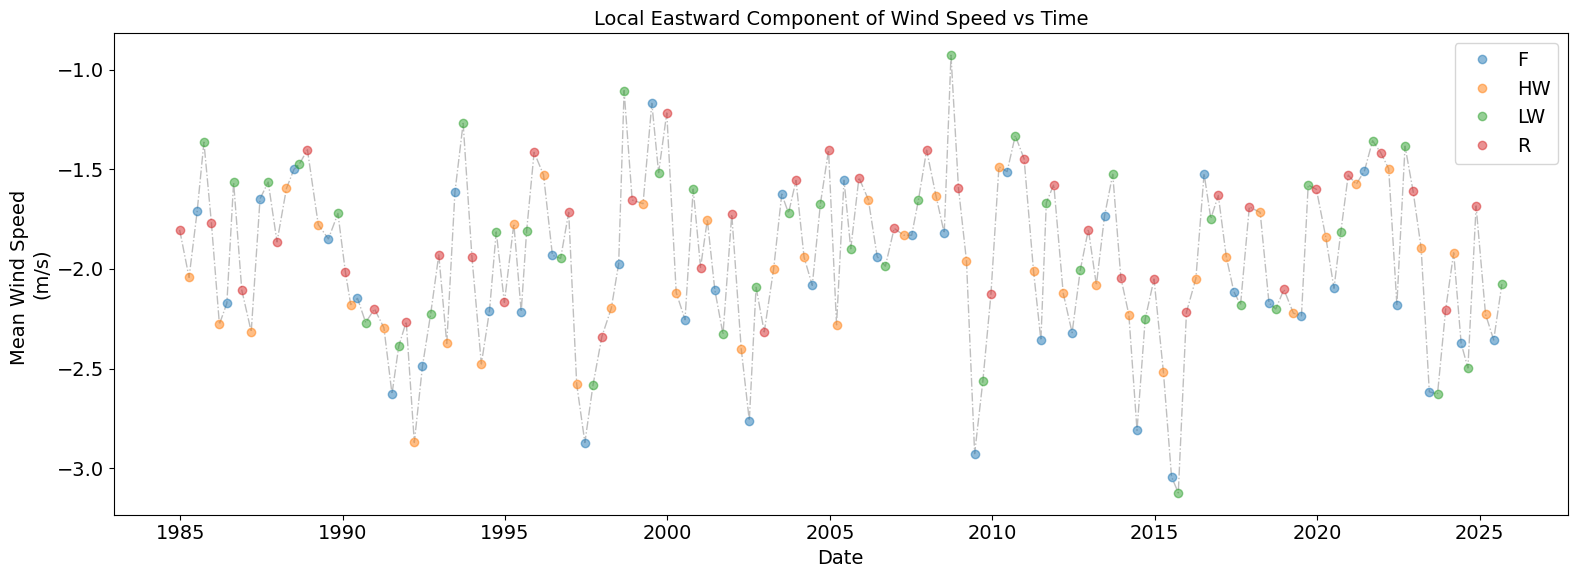

In [ ]:
# Create and display time series plot for local watershed eastward wind component over time
prepare_time_series_plot(df, 'u_wind_loc', "Local Eastward Component of Wind Speed")

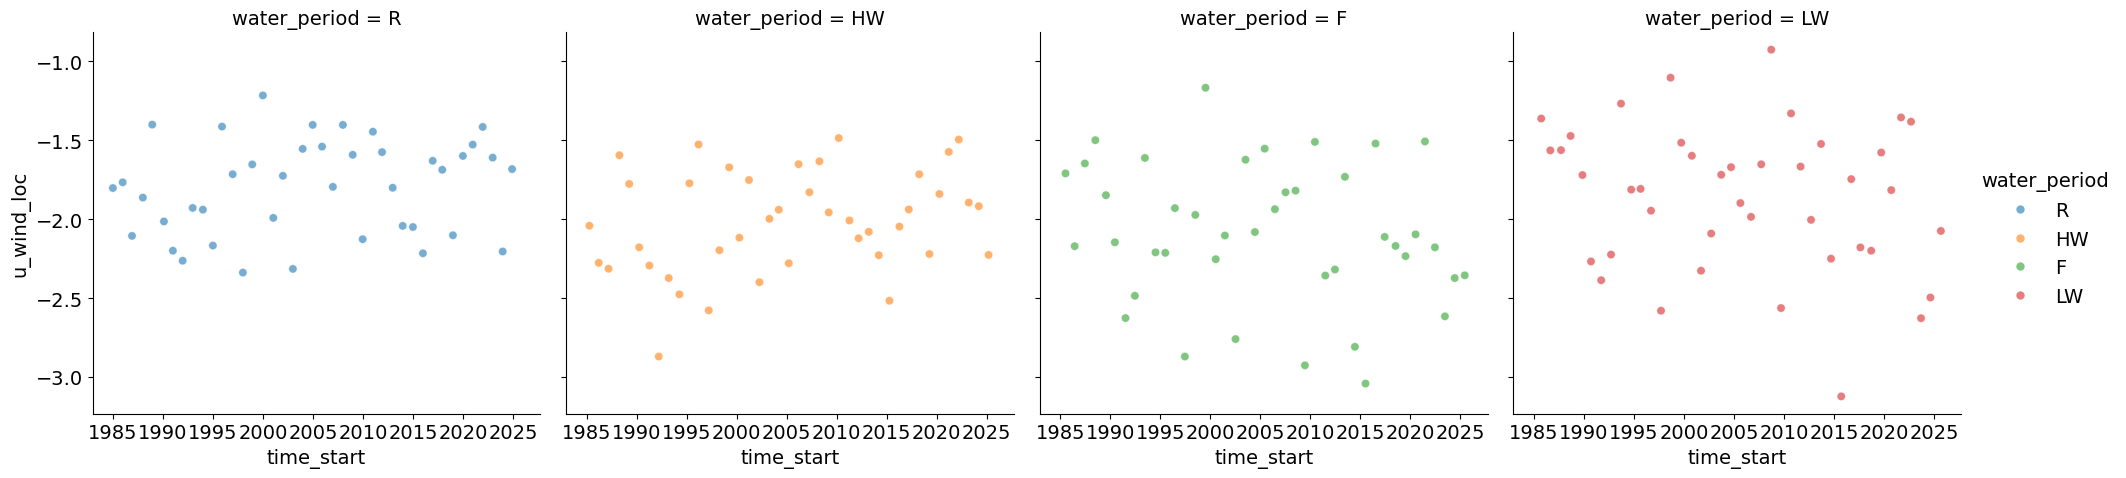

In [ ]:
# Create separate scatter plots showing local eastward wind component for each water period over time
sns.relplot(data=df, x='time_start', y='u_wind_loc', alpha=.6, hue='water_period', col='water_period')

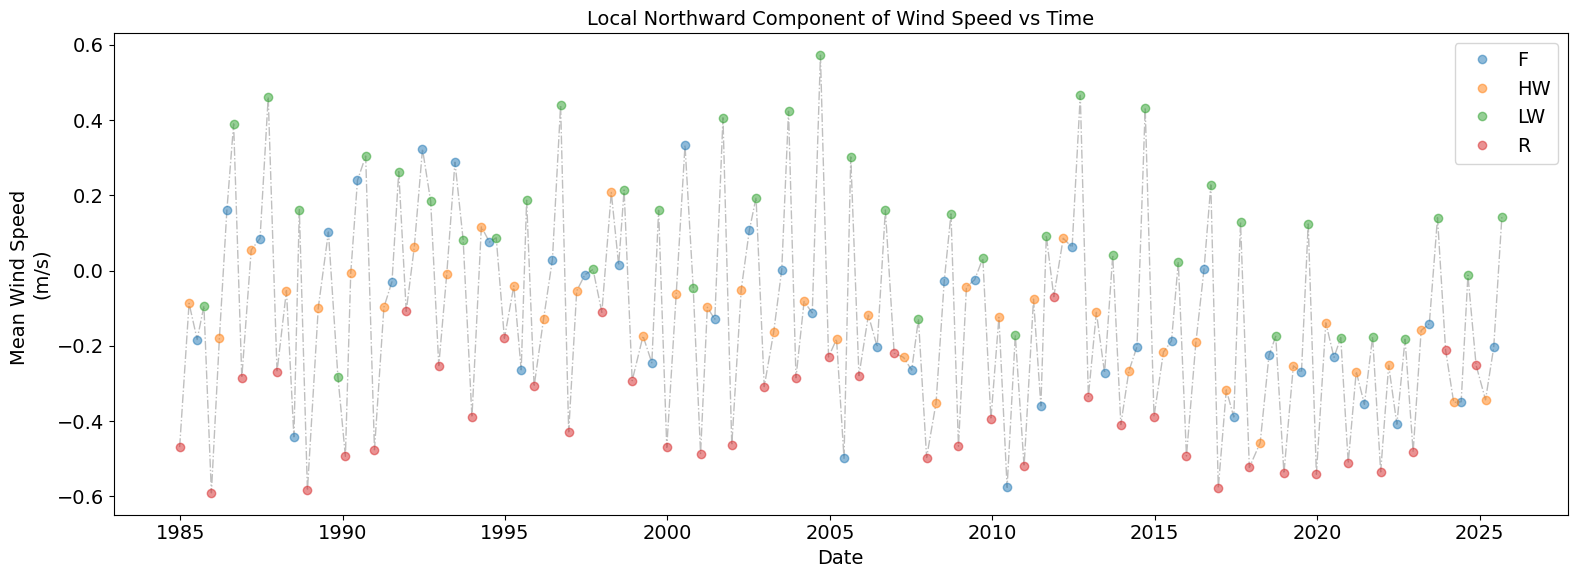

In [ ]:
# Create and display time series plot for local watershed northward wind component over time
prepare_time_series_plot(df, 'v_wind_loc', "Local Northward Component of Wind Speed")

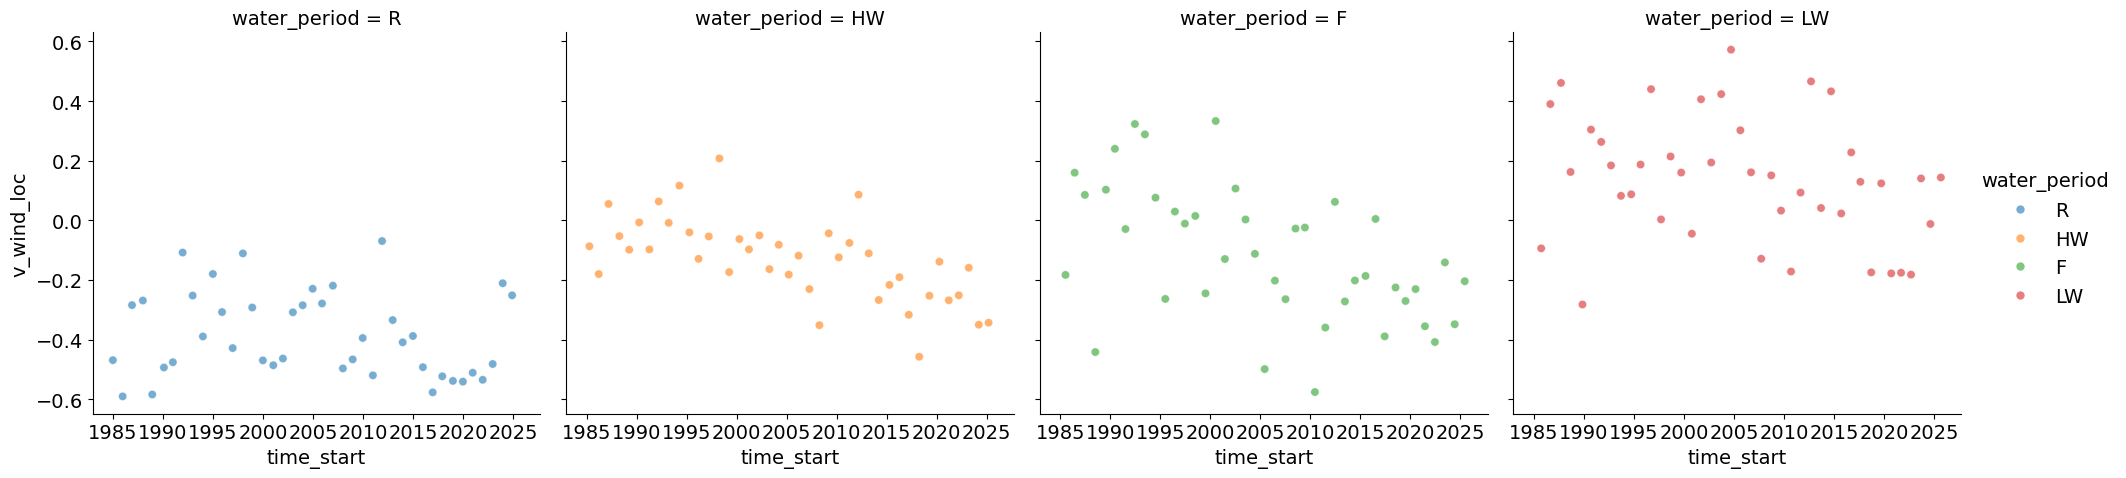

In [ ]:
# Create separate scatter plots showing local northward wind component for each water period over time
sns.relplot(data=df, x='time_start', y='v_wind_loc', alpha=.6, hue='water_period', col='water_period')

## Mean Wind Speed in Regional Watershed

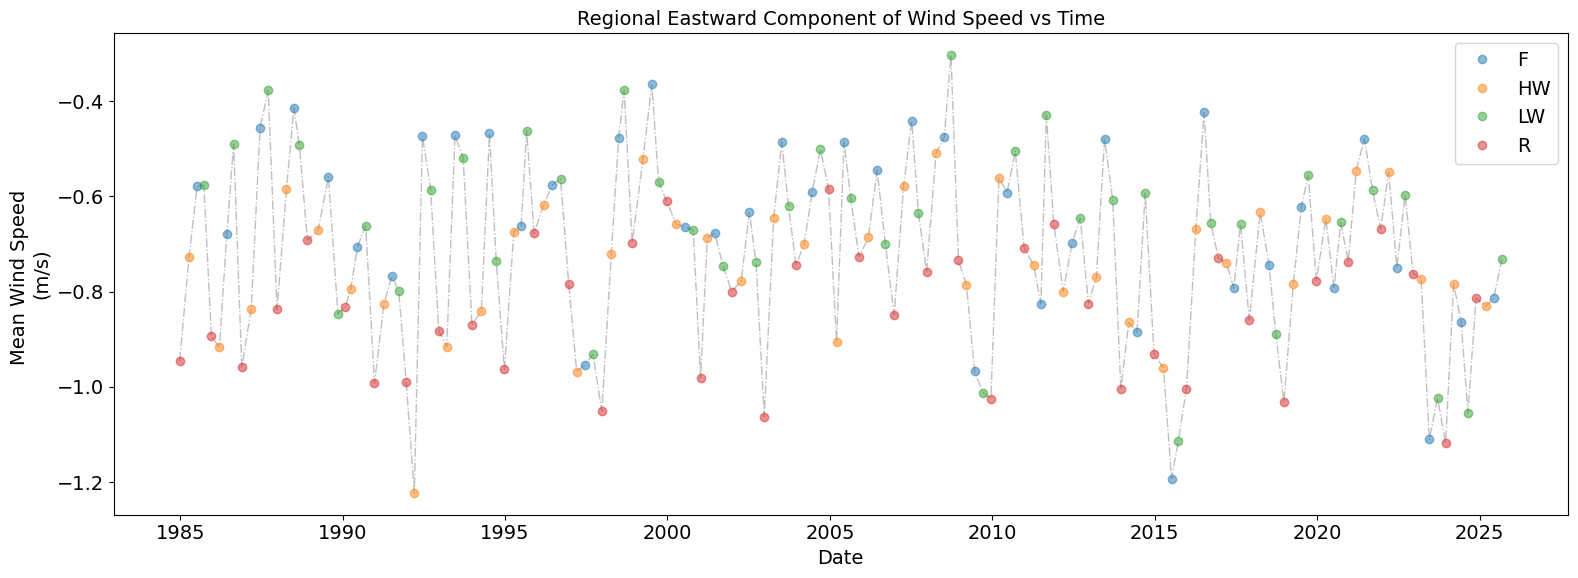

In [ ]:
# Create and display time series plot for regional watershed eastward wind component over time
prepare_time_series_plot(df, 'u_wind_reg', "Regional Eastward Component of Wind Speed")

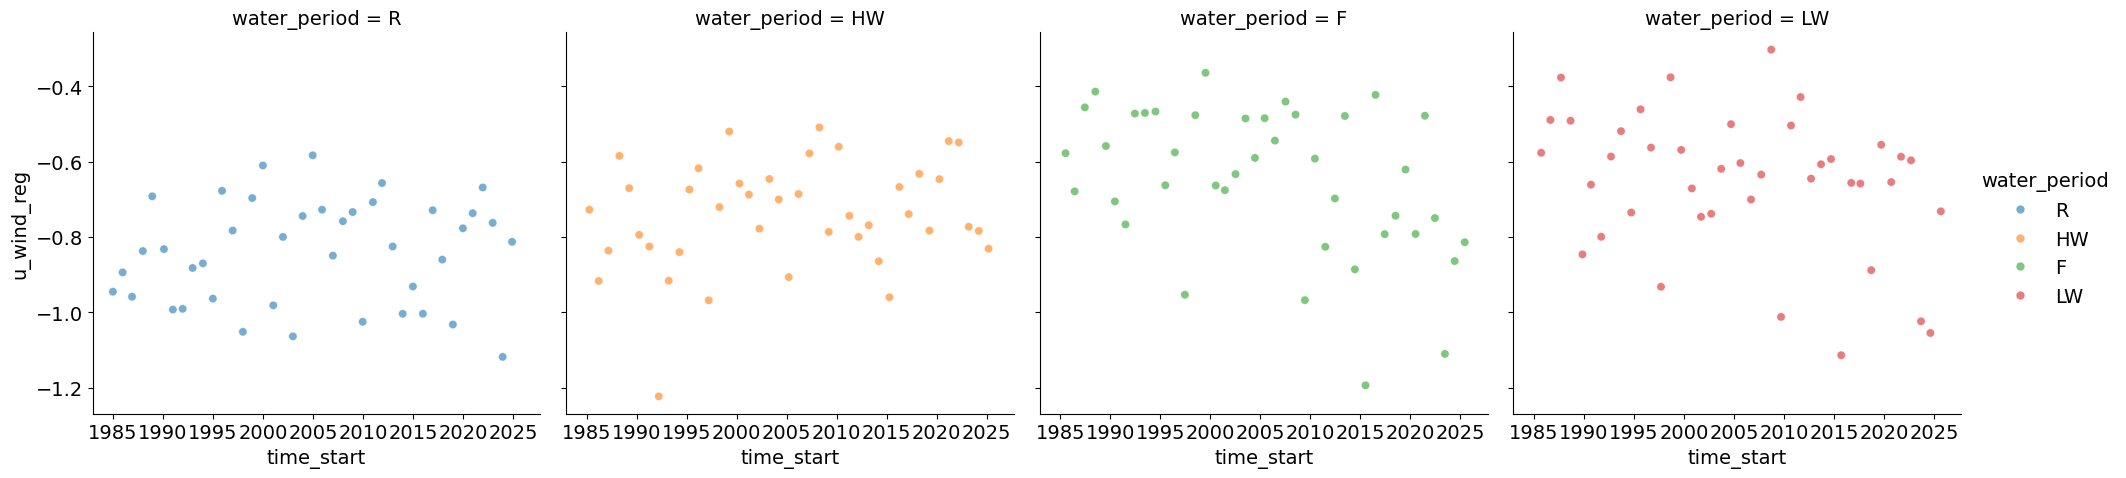

In [ ]:
# Create separate scatter plots showing regional eastward wind component for each water period over time
sns.relplot(data=df, x='time_start', y='u_wind_reg', alpha=.6, hue='water_period', col='water_period')

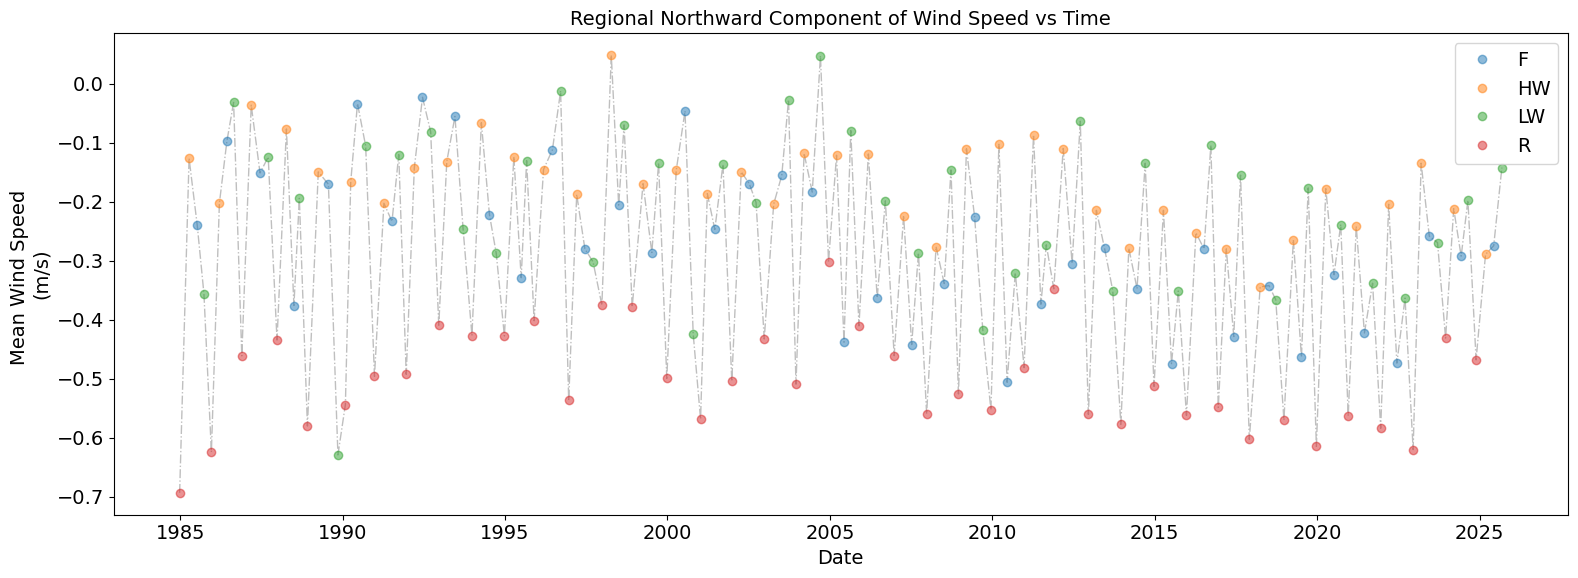

In [ ]:
# Create and display time series plot for regional watershed northward wind component over time
prepare_time_series_plot(df, 'v_wind_reg', "Regional Northward Component of Wind Speed")

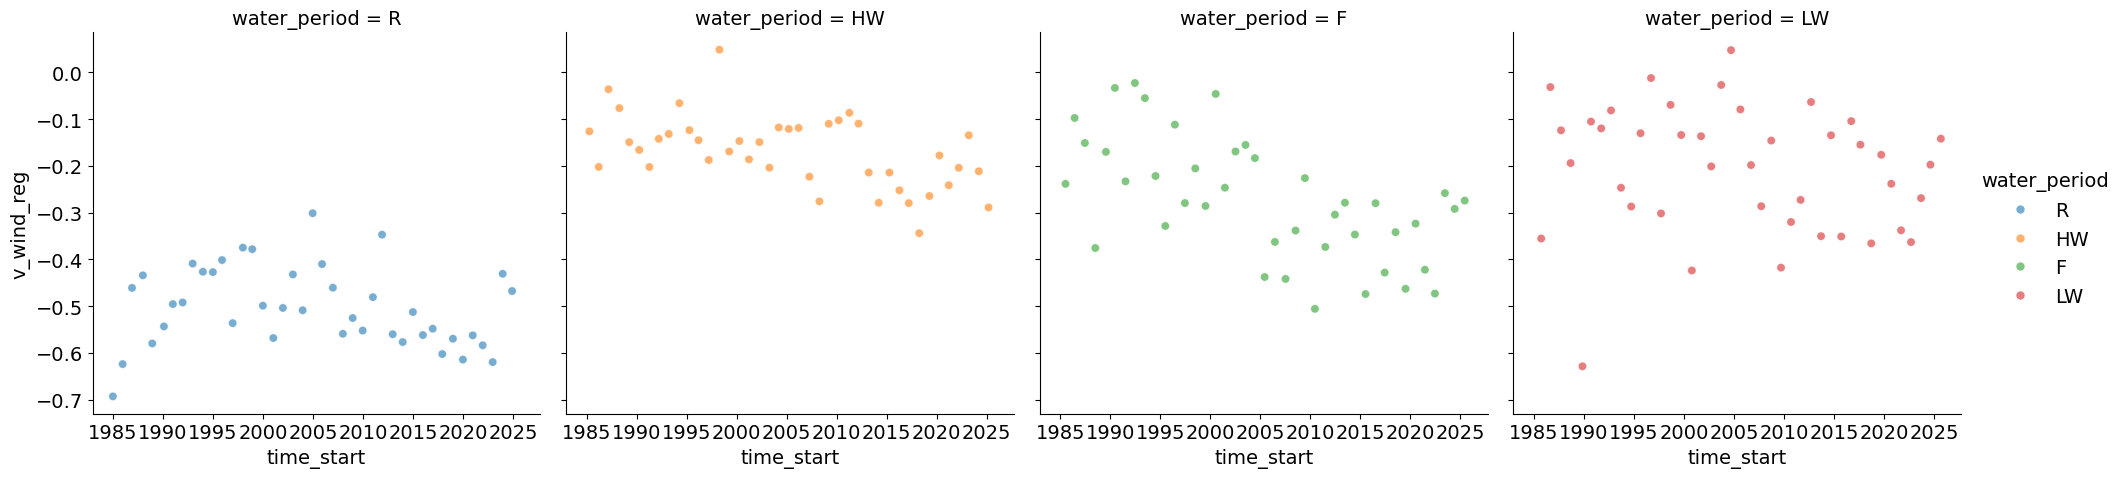

In [ ]:
# Create separate scatter plots showing regional northward wind component for each water period over time
sns.relplot(data=df, x='time_start', y='v_wind_reg', alpha=.6, hue='water_period', col='water_period')